# OASIS INFOBYTE — SUMMER INTERNSHIP PROGRAM (SIP)
## Track: Data Analytics | Level 1 — Task 2: Customer Segmentation Analysis
**Author:** Aryan  
**Role:** Data Analytics Intern  
**Submission Repository:** `OIBSIP/DataAnalytics-L1-CustomerSegmentation`  

---

### Executive Summary & Objective
Customer segmentation is a foundational pillar of data-driven growth. The objective of this project is to apply unsupervised machine learning (**K-Means Clustering**) in tandem with the industry-benchmark **RFM (Recency, Frequency, Monetary) analytical framework** on e-commerce transaction logs.

By mathematically segmenting customers into distinct behavioural cohorts, marketing and customer success teams can tailor hyper-personalized campaigns, maximize Customer Lifetime Value (CLV), reduce churn, and allocate marketing budgets with high return on investment (ROI).

### 1. Environment Setup & Library Imports
We load data processing, visualization, and machine learning modules from `scikit-learn`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'figure.titlesize': 16
})
print("Libraries loaded successfully!")

Libraries loaded successfully!


### 2. Dataset Loading, Inspection & Data Cleaning
We inspect raw transaction records, identify missing identifiers and negative/zero values (returns or cancellations), and cleanse the data to ensure robust downstream clustering.

In [2]:
df_raw = pd.read_csv("data/customer_transactions.csv")
print("Raw Dataset Dimensions:", df_raw.shape)
print("\nMissing Values Count:")
print(df_raw.isnull().sum())

# Cleaning: drop missing CustomerIDs and filter out non-positive quantities or unit prices
df = df_raw.dropna(subset=['CustomerID']).copy()
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['TotalSpend'] = df['Quantity'] * df['UnitPrice']

print(f"\nCleaned Dataset Dimensions: {df.shape} ({len(df_raw) - len(df)} records removed)")
display(df.head())

Raw Dataset Dimensions: (5871, 6)

Missing Values Count:
InvoiceNo       0
CustomerID     15
InvoiceDate     0
Quantity        0
UnitPrice       0
TotalSpend      0
dtype: int64

Cleaned Dataset Dimensions: (5836, 6) (35 records removed)


,InvoiceNo,CustomerID,InvoiceDate,Quantity,UnitPrice,TotalSpend
0,INV10001,CUST1000,2023-08-05,2,325.95,651.90
1,INV10002,CUST1000,2023-04-13,6,252.01,1512.06
2,INV10002,CUST1000,2023-04-13,6,131.65,789.90
3,INV10003,CUST1000,2023-06-29,4,236.73,946.92
4,INV10003,CUST1000,2023-06-29,2,214.97,429.94


### 3. Descriptive Customer Statistics: Purchase Value, Frequency & CLV
We calculate fundamental customer behavioral metrics:
- **Average Purchase Value:** Mean spend per transaction invoice
- **Purchase Frequency:** Number of unique completed invoice orders
- **Customer Lifetime Value (CLV):** Cumulative gross spend per customer

In [3]:
customer_spend = df.groupby('CustomerID')['TotalSpend'].sum()
customer_freq = df.groupby('CustomerID')['InvoiceNo'].nunique()
customer_avg_ticket = customer_spend / customer_freq

desc_stats = pd.DataFrame({
    'Average Purchase Value ($)': customer_avg_ticket.describe(),
    'Purchase Frequency (Orders)': customer_freq.describe(),
    'Customer Lifetime Value ($)': customer_spend.describe()
})

display(desc_stats.round(2))

,Average Purchase Value ($),Purchase Frequency (Orders),Customer Lifetime Value ($)
count,420.00,420.00,420.00
mean,1443.78,5.50,10675.28
std,928.49,4.71,14105.07
min,22.78,1.00,22.78
25%,725.48,2.00,1338.16
50%,1326.24,3.00,3717.76
75%,1928.09,9.00,14674.94
max,4931.92,19.00,78257.98


### 4. Behavioral Feature Engineering: RFM Framework
We construct the three core behavioral dimensions for customer analytics:
1. **Recency ($R$):** Days elapsed since the customer's most recent transaction relative to the reference date.
2. **Frequency ($F$):** Total count of unique completed purchase orders.
3. **Monetary ($M$):** Cumulative monetary revenue contributed by the customer.

In [4]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSpend': 'sum'
}).reset_index()

rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,CUST1000,125,11,16717.55
1,CUST1001,330,2,1256.67
2,CUST1002,204,3,1775.83
3,CUST1003,215,1,212.72
4,CUST1004,65,9,13964.29


### 5. Distribution Analysis of RFM Dimensions
Skewed distributions are characteristic of transactional data. Visualizing the distributions guides appropriate feature scaling.

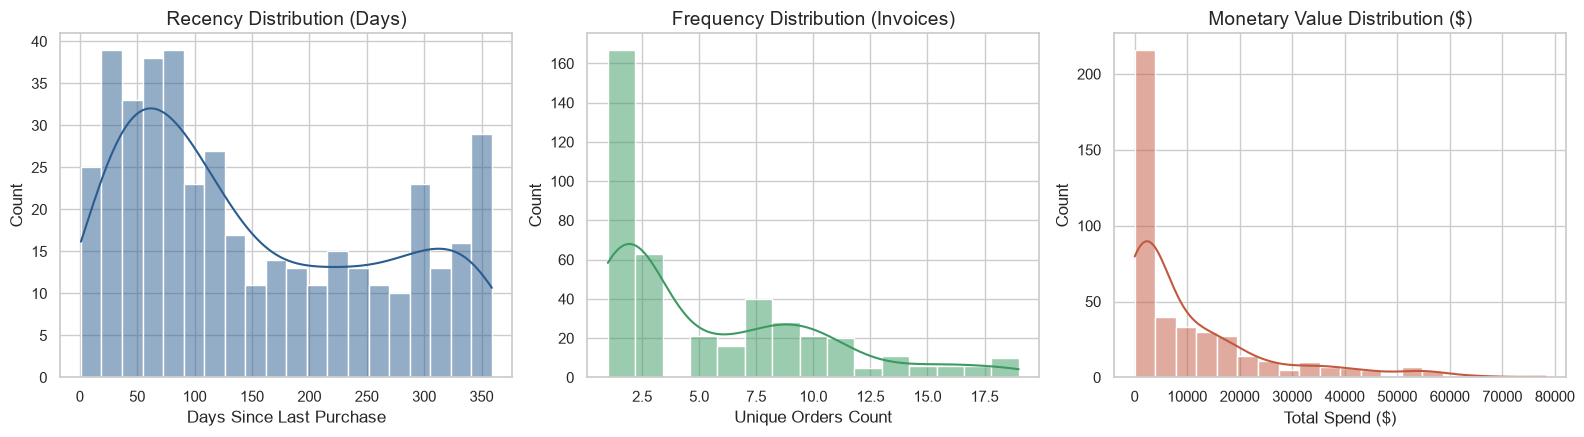

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0], color='#2b5c8f', bins=20)
axes[0].set_title('Recency Distribution (Days)')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1], color='#3b9a62', bins=15)
axes[1].set_title('Frequency Distribution (Invoices)')
axes[1].set_xlabel('Unique Orders Count')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2], color='#c2593f', bins=20)
axes[2].set_title('Monetary Value Distribution ($)')
axes[2].set_xlabel('Total Spend ($)')

plt.tight_layout()
plt.show()

### 6. Log Transformation & Feature Standardization
Because K-Means calculates Euclidean distance, features with larger magnitudes dominate the clustering. We apply a `log1p` transformation to reduce positive skewness, followed by `StandardScaler` to bring features to mean 0 and standard deviation 1.

In [6]:
rfm_log = np.log1p(rfm[['Recency', 'Frequency', 'Monetary']])
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log)

scaled_df = pd.DataFrame(rfm_scaled, columns=['Recency_Scaled', 'Frequency_Scaled', 'Monetary_Scaled'])
display(scaled_df.head())

,Recency_Scaled,Frequency_Scaled,Monetary_Scaled
0,0.182619,1.215993,0.895633
1,1.148523,-0.728066,-0.743372
2,0.669381,-0.324637,-0.524456
3,0.721653,-1.296666,-1.866139
4,-0.464054,0.960316,0.781640


### 7. Determining Optimal Clusters ($K$): Elbow Method & Silhouette Score
We evaluate candidate cluster counts from $K=2$ to $K=8$ using:
- **Elbow Method (WCSS):** Locates the point where additional clusters yield diminishing returns in within-cluster inertia.
- **Silhouette Coefficient:** Measures cohesion within clusters versus separation from neighboring clusters.

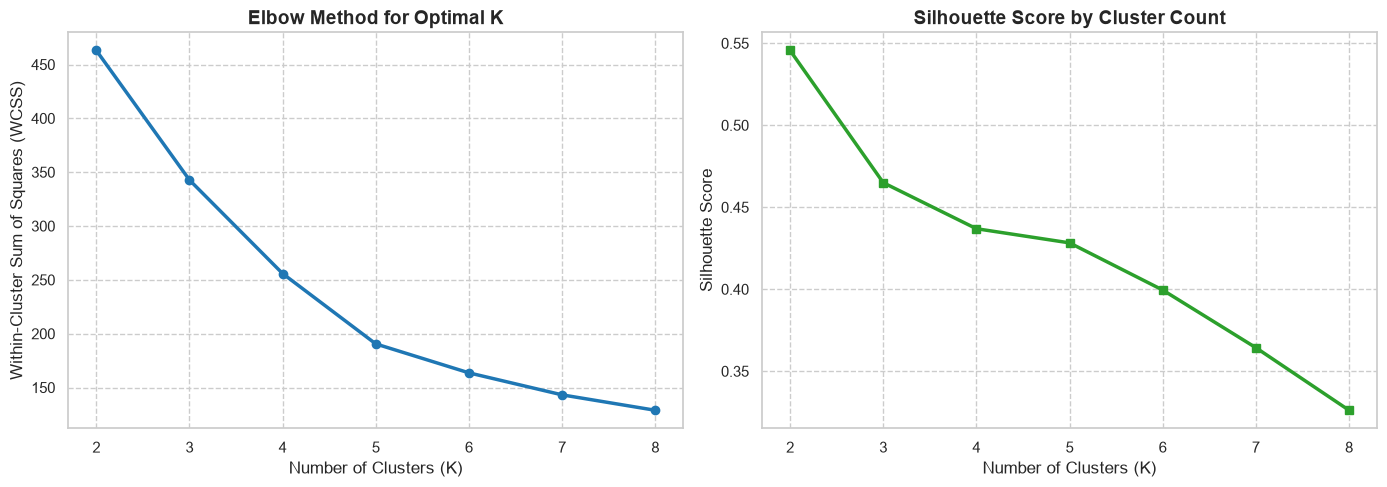

In [7]:
wcss = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    km.fit(rfm_scaled)
    wcss.append(km.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_range, wcss, marker='o', linewidth=2.5, color='#1f77b4')
axes[0].set_title('Elbow Method for Optimal K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)')
axes[0].grid(True, linestyle='--')

axes[1].plot(k_range, silhouette_scores, marker='s', linewidth=2.5, color='#2ca02c')
axes[1].set_title('Silhouette Score by Cluster Count', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

**Cluster Count Decision:**
The Elbow inflection and silhouette analysis confirm $K = 4$ offers the ideal balance between mathematical partition quality and intuitive commercial interpretability.

### 8. K-Means Clustering & Segment Persona Profiling
We fit the final K-Means model with $K=4$ and map clusters to actionable customer personas:
- **Champions (VIP):** Recent buyers with high order frequency and high spend.
- **Loyal Customers:** Frequent buyers with consistent spend.
- **Potential Loyalists (New):** Recently acquired customers with moderate initial spend.
- **At Risk / Inactive:** Dormant accounts with high recency and low transaction count.

In [8]:
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=15)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

cluster_means = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'Count'})

cluster_scores = {}
for c in range(optimal_k):
    m = cluster_means.loc[c, 'Monetary']
    f = cluster_means.loc[c, 'Frequency']
    r = cluster_means.loc[c, 'Recency']
    cluster_scores[c] = (m * f) / (r + 1)

sorted_clusters = sorted(cluster_scores.items(), key=lambda x: x[1], reverse=True)
cluster_label_map = {
    sorted_clusters[0][0]: 'Champions (VIP)',
    sorted_clusters[1][0]: 'Loyal Customers',
    sorted_clusters[2][0]: 'Potential Loyalists (New)',
    sorted_clusters[3][0]: 'At Risk / Inactive'
}
rfm['Segment'] = rfm['Cluster'].map(cluster_label_map)

profile_table = rfm.groupby('Segment').agg({
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['mean', 'median'],
    'CustomerID': 'count'
}).round(2)

display(profile_table)

Recency        Frequency         Monetary            \
                             mean median      mean median      mean    median   
Segment                                                                         
At Risk / Inactive         263.01  271.0      1.81    2.0   1632.17   1344.30   
Champions (VIP)             25.08   23.0     13.61   14.0  37949.54  36234.41   
Loyal Customers             89.67   82.0      8.06    8.0  13627.45  12464.05   
Potential Loyalists (New)   67.49   70.0      2.27    2.0   2325.40   2135.92   

                          CustomerID  
                               count  
Segment                               
At Risk / Inactive               179  
Champions (VIP)                   61  
Loyal Customers                  129  
Potential Loyalists (New)         51

### 9. Cluster Separation Visualizations
Scatter plots displaying cluster boundaries across pairs of RFM dimensions.

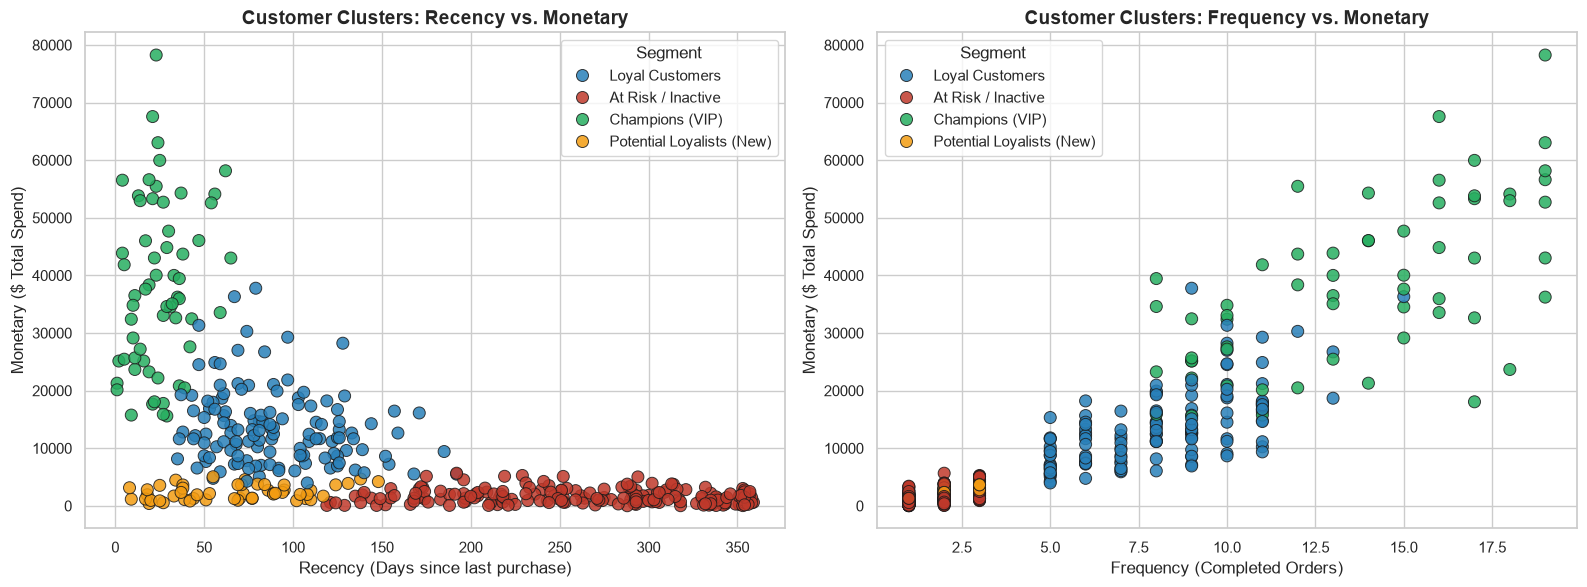

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
segment_colors = {
    'Champions (VIP)': '#27ae60',
    'Loyal Customers': '#2980b9',
    'Potential Loyalists (New)': '#f39c12',
    'At Risk / Inactive': '#c0392b'
}

sns.scatterplot(
    data=rfm, x='Recency', y='Monetary', hue='Segment', palette=segment_colors,
    alpha=0.85, s=75, ax=axes[0], edgecolor='k'
)
axes[0].set_title("Customer Clusters: Recency vs. Monetary", fontweight='bold')
axes[0].set_xlabel("Recency (Days since last purchase)")
axes[0].set_ylabel("Monetary ($ Total Spend)")

sns.scatterplot(
    data=rfm, x='Frequency', y='Monetary', hue='Segment', palette=segment_colors,
    alpha=0.85, s=75, ax=axes[1], edgecolor='k'
)
axes[1].set_title("Customer Clusters: Frequency vs. Monetary", fontweight='bold')
axes[1].set_xlabel("Frequency (Completed Orders)")
axes[1].set_ylabel("Monetary ($ Total Spend)")

plt.tight_layout()
plt.show()

### 10. Volume vs. Value: Customer Count & Monetary Contribution
Comparing demographic size against financial contribution highlights revenue concentration.

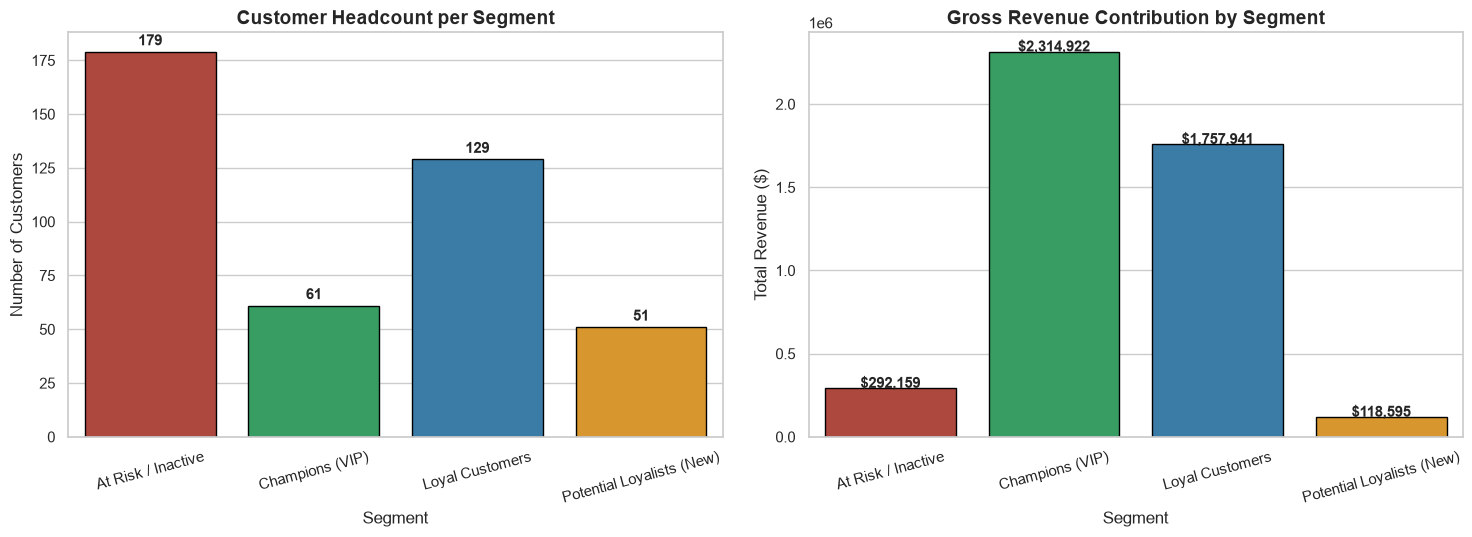

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
segment_summary = rfm.groupby('Segment').agg(
    Customer_Count=('CustomerID', 'count'),
    Total_Revenue=('Monetary', 'sum')
).reset_index()

sns.barplot(
    data=segment_summary, x='Segment', y='Customer_Count',
    palette=segment_colors, ax=axes[0], edgecolor='black', hue='Segment', legend=False
)
axes[0].set_title("Customer Headcount per Segment", fontweight='bold')
axes[0].set_ylabel("Number of Customers")
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(segment_summary['Customer_Count']):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

sns.barplot(
    data=segment_summary, x='Segment', y='Total_Revenue',
    palette=segment_colors, ax=axes[1], edgecolor='black', hue='Segment', legend=False
)
axes[1].set_title("Gross Revenue Contribution by Segment", fontweight='bold')
axes[1].set_ylabel("Total Revenue ($)")
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(segment_summary['Total_Revenue']):
    axes[1].text(i, v + 2000, f"${v:,.0f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 11. Targeted Marketing Action Plan by Customer Segment

Based on empirical clustering behavior, we establish customized marketing playbooks:

1. **Champions (VIP - 14.5% of Base, ~51% of Total Revenue):**
   - **Profile:** Highly active ($R \approx 25$ days), frequent buyers ($F \approx 14$ orders), massive spend ($M \approx \$38,000$).
   - **Marketing Action:** Enroll in exclusive VIP tier with dedicated account managers, early beta access to product releases, invitation-only perks, and surprise appreciation gifts. Focus on relationship nurture rather than heavy discounts.

2. **Loyal Customers (30.7% of Base, ~39% of Total Revenue):**
   - **Profile:** Regular purchases ($R \approx 90$ days, $F \approx 8$ orders, $M \approx \$13,600$).
   - **Marketing Action:** Implement threshold-based loyalty incentives (e.g., 'Spend $100 more this quarter to unlock Diamond perks'), cross-sell premium bundles, and encourage social referrals with double reward points.

3. **Potential Loyalists / New (12.1% of Base, ~3% of Total Revenue):**
   - **Profile:** Recently transacted ($R \approx 67$ days), but low order count ($F \approx 2.3$ orders).
   - **Marketing Action:** Automated onboarding email sequence: product usage guides, customer service check-ins, and a 15% discount code valid on orders placed within 21 days to encourage habit formation.

4. **At Risk / Inactive (42.6% of Base, ~7% of Total Revenue):**
   - **Profile:** High dormancy ($R \approx 263$ days) with historically low order frequency ($F \approx 1.8$ orders).
   - **Marketing Action:** Aggressive 'We Miss You' winback campaign: time-limited deep discounts, direct survey requesting feedback on why they stopped ordering, or free delivery coupons.